# Регрессия доходности нефтяных «голубых фишек»

Прогноз будущей доходности (`target_return = close[t+h]/close[t] - 1`) ансамблем LSTM с проверкой устойчивости.
Это исследовательский инструмент поддержки решений, а не инвестиционная рекомендация; учитывая шум финансовых рядов, ожидания скромные — цель — устойчивое преимущество в направлении над базовой стратегией.

**Что внутри:** единый `CONFIG`; защита от утечки (RobustScaler обучается только на train, между train и валидацией ставится эмбарго в `horizon` дней); ансамбль по сидам; walk-forward по времени; интерпретируемые метрики (directional accuracy против buy&hold, информационный коэффициент IC, hit-rate на уверенных прогнозах, разбивка по тикерам); permutation importance с разбросом.

In [ ]:
import os, random, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr
from sklearn.preprocessing import RobustScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
warnings.filterwarnings('ignore')

from google.colab import drive; drive.mount('/content/drive')

def set_seed(s):
    os.environ['PYTHONHASHSEED'] = str(s)
    random.seed(s); np.random.seed(s); tf.random.set_seed(s)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
CONFIG = {
    # --- данные ---
    'data_path'      : '/content/drive/MyDrive/full_df_sector.csv',
    'date_start'     : '2015-01-01',
    'date_end'       : '2021-12-31',
    'exclude_tickers': ['SNGS', 'SNGSP'],                # обыкновенный Сургут ведёт себя как валютная ставка
    # мёртвые/служебные/утечные столбцы — убираем сразу
    'drop_columns'   : ['shares_out', 'market_cap', 'Spread_Percent', 'next_div_date'],

    # --- постановка ---
    'horizon'        : 5,    # на сколько дней вперёд считаем доходность (h)
    'window_size'    : 20,   # длина входного окна (история)

    # столбцы, которые переводим в доходности (pct_change) внутри тикера
    'pct_change_cols': ['imoex', 'rgbi', 'rvi', 'brent', 'usd_rub', 'sp500', 'M2', 'volume', 'value', 'cny_rub'],
    # сырые уровни цен/объёмов, которые НЕ подаём как признаки (нестационарны)
    'exclude_features': ['Date', 'target_return', 'close', 'target', 'open', 'high', 'low',
                         'sma_5', 'sma_10', 'sma_20'],

    # --- схема валидации ---
    'scheme'         : 'walk_forward',  # 'walk_forward' | 'holdout'
    'n_folds'        : 4,               # число фолдов для walk_forward
    'val_size'       : 150,             # размер валидационного блока (торговых дней) на фолд
    'holdout_frac'   : 0.2,             # доля валидации для scheme='holdout'

    # --- ансамбль и модель ---
    'seeds'          : [42, 123, 777, 2024, 7],   # размер ансамбля = длине списка
    'model'          : {'lstm_units': [64, 32], 'dropout': 0.2, 'dense_units': [16],
                        'lr': 5e-4, 'loss': 'huber', 'epochs': 80, 'batch_size': 64, 'patience': 8},

    # --- интерпретация ---
    'conf_quantile'  : 0.70,   # «уверенные» прогнозы = верхние (1-q) по |прогноз|
    'perm_repeats'   : 3,      # повторов в permutation importance

    # --- сохранение ---
    'save_dir'       : None,
}

## 1. Загрузка и фильтрация данных

In [ ]:
df = pd.read_csv(CONFIG['data_path'])
df['Date'] = pd.to_datetime(df['Date'])

df = df[df['Date'].between(CONFIG['date_start'], CONFIG['date_end'])]
df = df[~df['ticker'].isin(CONFIG['exclude_tickers'])]
df = df.drop(columns=[c for c in CONFIG['drop_columns'] if c in df.columns])

print('Период:', df['Date'].min().date(), '—', df['Date'].max().date())
print('Тикеры:', sorted(df['ticker'].unique()))
print('Строк:', len(df))
df.head()

Период: 2015-01-05 — 2021-12-30
Тикеры: ['BANE', 'BANEP', 'GAZP', 'LKOH', 'NVTK', 'ROSN', 'SIBN', 'TATN', 'TATNP']
Строк: 15885


,Date,close,ticker,open,high,low,value,volume,target,sma_5,...,sp500,fed_rate_proxy,cny_rub,M2,rate,rate_is_changed,dividend_val,ROE,m2_is_new,days_to_div
0,2015-01-05,142.0,SIBN,140.2,145.9,139.3,2.289392e+06,16230,144.60,142.48,...,2020.579956,0.003,9.48177,30142.0,17.0,0.0,0.0,0.050,0,168.0
2,2015-01-05,238.0,TATN,228.5,238.0,225.4,2.701104e+08,1164410,228.75,235.30,...,2020.579956,0.003,9.48177,30142.0,17.0,0.0,0.0,0.041,0,191.0
3,2015-01-05,2295.0,LKOH,2201.0,2317.0,2200.9,1.297335e+09,567928,2345.00,2257.72,...,2020.579956,0.003,9.48177,30142.0,17.0,0.0,0.0,0.020,0,190.0
4,2015-01-05,134.7,TATNP,132.0,136.8,130.7,4.189670e+06,30710,135.30,134.86,...,2020.579956,0.003,9.48177,30142.0,17.0,0.0,0.0,0.041,0,1278.0
5,2015-01-05,455.5,NVTK,432.6,457.5,430.5,3.458338e+08,771110,476.70,434.32,...,2020.579956,0.003,9.48177,30142.0,17.0,0.0,0.0,NaN,0,1374.0


## 2. Формирование признаков и таргета

Таргет — доходность через `horizon` дней. Макро и объёмы переводим в доходности (`pct_change`), цены — в относительные величины. Тикеры кодируем one-hot, чтобы одна модель обучалась на пуле всех бумаг и при этом «знала», какая это бумага. Утечки нет: все преобразования используют только прошлое внутри своего тикера, масштабирование — позже и только на train.

In [ ]:
def prepare_data(df, cfg):
    data = df.copy().sort_values(['ticker', 'Date'])

    # целевая переменная: доходность через horizon дней
    h = cfg['horizon']
    data['target_return'] = data.groupby('ticker')['close'].shift(-h) / data['close'] - 1

    # переводим макро/объёмы в доходности (на месте)
    for col in cfg['pct_change_cols']:
        if col in data.columns:
            data[col] = data.groupby('ticker')[col].pct_change()

    # собственная дневная доходность бумаги
    data['stock_ret_1d'] = data.groupby('ticker')['close'].pct_change()

    # дешёвый интерпретируемый признак из OHLC: относительный дневной диапазон
    if {'high', 'low'}.issubset(data.columns):
        data['range_pct'] = (data['high'] - data['low']) / data['close']

    # one-hot тикеров (как числа 0/1)
    data = pd.get_dummies(data, columns=['ticker'], prefix='ticker', dtype=float)

    feature_cols = [c for c in data.columns if c not in cfg['exclude_features']]

    # чистим бесконечности/пропуски, появившиеся из-за pct_change и shift
    data = data.replace([np.inf, -np.inf], np.nan).dropna(subset=feature_cols + ['target_return'])
    return data, feature_cols

df_clean, FEATURES = prepare_data(df, CONFIG)
W = CONFIG['window_size']
print(f'Признаков: {len(FEATURES)}')
print(FEATURES)
print('Строк после очистки:', len(df_clean))

Признаков: 31
['value', 'volume', 'dist_sma_5', 'dist_sma_10', 'dist_sma_20', 'imoex', 'rgbi', 'rvi', 'brent', 'usd_rub', 'sp500', 'fed_rate_proxy', 'cny_rub', 'M2', 'rate', 'rate_is_changed', 'dividend_val', 'ROE', 'm2_is_new', 'days_to_div', 'stock_ret_1d', 'range_pct', 'ticker_BANE', 'ticker_BANEP', 'ticker_GAZP', 'ticker_LKOH', 'ticker_NVTK', 'ticker_ROSN', 'ticker_SIBN', 'ticker_TATN', 'ticker_TATNP']
Строк после очистки: 15339


In [ ]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 15339 entries, 1147 to 19356
Data columns (total 41 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Date             15339 non-null  datetime64[ns]
 1   close            15339 non-null  float64       
 2   open             15339 non-null  float64       
 3   high             15339 non-null  float64       
 4   low              15339 non-null  float64       
 5   value            15339 non-null  float64       
 6   volume           15339 non-null  float64       
 7   target           15339 non-null  float64       
 8   sma_5            15339 non-null  float64       
 9   dist_sma_5       15339 non-null  float64       
 10  sma_10           15339 non-null  float64       
 11  dist_sma_10      15339 non-null  float64       
 12  sma_20           15339 non-null  float64       
 13  dist_sma_20      15339 non-null  float64       
 14  imoex            15339 non-null  float64

## 3. Вспомогательные функции (последовательности, масштабирование, метрики, модель)

In [ ]:
def create_sequences(frame, feature_cols, window_size, target_col='target_return'):
    """Окна строятся отдельно по каждому тикеру (без смешивания). Возвращает X, y и
    даты/тикеры точки прогноза — для разбивки результатов."""
    Xs, ys, ds, ts = [], [], [], []
    ticker_cols = [c for c in frame.columns if c.startswith('ticker_')]
    for tcol in ticker_cols:
        sub = frame[frame[tcol] == 1.0].sort_values('Date')
        if len(sub) <= window_size:
            continue
        feats = sub[feature_cols].values.astype('float32')
        tgt   = sub[target_col].values.astype('float32')
        dates = sub['Date'].values
        name  = tcol.replace('ticker_', '')
        for i in range(window_size, len(sub)):
            Xs.append(feats[i - window_size:i]); ys.append(tgt[i])
            ds.append(dates[i]); ts.append(name)
    return np.array(Xs), np.array(ys), np.array(ds), np.array(ts)


def scale_fold(train_df, val_df, feature_cols):
    """RobustScaler обучается ТОЛЬКО на train. Бинарные признаки не масштабируем."""
    binary = [c for c in feature_cols if c.startswith('ticker_')
              or c.endswith('is_changed') or c.endswith('is_new')]
    scale_cols = [c for c in feature_cols if c not in binary]
    sc = RobustScaler()
    tr, va = train_df.copy(), val_df.copy()
    tr[scale_cols] = sc.fit_transform(tr[scale_cols])
    va[scale_cols] = sc.transform(va[scale_cols])
    tr[feature_cols] = tr[feature_cols].astype('float32')
    va[feature_cols] = va[feature_cols].astype('float32')
    return tr, va, sc


def reg_metrics(y, p, conf_q=0.70):
    y = np.asarray(y).flatten(); p = np.asarray(p).flatten()
    da = float(np.mean(np.sign(y) == np.sign(p)))          # угадывание направления
    bh = float(np.mean(y > 0))                              # базовая стратегия "всегда вверх"
    ic = float(np.corrcoef(p, y)[0, 1]) if np.std(p) > 0 else np.nan   # информационный коэффициент
    sic = float(spearmanr(p, y).correlation)
    mae = float(np.mean(np.abs(y - p))); rmse = float(np.sqrt(np.mean((y - p) ** 2)))
    thr = np.quantile(np.abs(p), conf_q)                   # hit-rate на уверенных прогнозах
    m = np.abs(p) >= thr
    cda = float(np.mean(np.sign(y[m]) == np.sign(p[m]))) if m.sum() > 0 else np.nan
    return {'DA': da, 'B&H': bh, 'edge': da - bh, 'IC': ic, 'IC_sp': sic,
            'conf_DA': cda, 'MAE': mae, 'RMSE': rmse, 'up_rate': float(np.mean(p > 0)), 'n': int(len(y))}


def build_model(input_shape, m):
    layers = [Input(shape=input_shape)]
    units = m['lstm_units']
    for j, u in enumerate(units):
        layers.append(LSTM(u, return_sequences=(j < len(units) - 1)))
        layers.append(Dropout(m['dropout']))
        if j == 0:
            layers.append(BatchNormalization())
    for du in m['dense_units']:
        layers.append(Dense(du, activation='relu'))
    layers.append(Dense(1))
    model = Sequential(layers)
    model.compile(optimizer=Adam(m['lr']), loss=m['loss'], metrics=['mae'])
    return model

## 4. Разбиение по времени (walk-forward с эмбарго)

Эмбарго в `horizon` дней между train и валидацией обязательно: таргет смотрит на `h` дней вперёд, поэтому последние `h` дней train «заглядывают» в валидацию — их выбрасываем.

In [ ]:
def make_splits(dates, cfg):
    dates = sorted(pd.unique(dates))
    h = cfg['horizon']
    if cfg['scheme'] == 'holdout':
        split = int(len(dates) * (1 - cfg['holdout_frac']))
        train = dates[:split - h]            # эмбарго
        val   = dates[split:]
        return [(train, val)]
    # walk_forward: расширяющееся окно train, последовательные блоки валидации в конце
    n, vs = cfg['n_folds'], cfg['val_size']
    first = len(dates) - n * vs
    if first < vs:
        raise ValueError('Недостаточно дат для заданных n_folds/val_size — уменьшите их в CONFIG.')
    splits = []
    for k in range(n):
        vstart = first + k * vs
        train = dates[:vstart - h]           # эмбарго
        val   = dates[vstart:vstart + vs]
        splits.append((train, val))
    return splits

SPLITS = make_splits(df_clean['Date'], CONFIG)
for k, (tr, va) in enumerate(SPLITS):
    print(f'Fold {k}: train {pd.Timestamp(tr[0]).date()}..{pd.Timestamp(tr[-1]).date()} '
          f'({len(tr)} дней) | val {pd.Timestamp(va[0]).date()}..{pd.Timestamp(va[-1]).date()} ({len(va)} дней)')

Fold 0: train 2015-01-06..2019-08-02 (1154 дней) | val 2019-08-12..2020-03-17 (150 дней)
Fold 1: train 2015-01-06..2020-03-10 (1304 дней) | val 2020-03-18..2020-10-20 (150 дней)
Fold 2: train 2015-01-06..2020-10-13 (1454 дней) | val 2020-10-21..2021-05-26 (150 дней)
Fold 3: train 2015-01-06..2021-05-19 (1604 дней) | val 2021-05-27..2021-12-23 (150 дней)


## 5. Обучение ансамбля по фолдам

Для каждого фолда масштабируем (fit только на train), строим окна, обучаем `len(seeds)` моделей с разными сидами и усредняем их прогнозы. Считаем метрики ансамбля по фолду и отдельно метрики каждой модели — чтобы видеть устойчивость и по времени (между фолдами), и по инициализации (между сидами).

In [ ]:
fold_rows, seed_rows = [], []
last = None
mcfg, seeds = CONFIG['model'], CONFIG['seeds']

for k, (tr_dates, va_dates) in enumerate(SPLITS):
    tr_df = df_clean[df_clean['Date'].isin(tr_dates)]
    va_df = df_clean[df_clean['Date'].isin(va_dates)]
    tr_s, va_s, sc = scale_fold(tr_df, va_df, FEATURES)

    Xtr, ytr, _, _   = create_sequences(tr_s, FEATURES, W)
    Xv, yv, dv, tv   = create_sequences(va_s, FEATURES, W)
    if len(Xtr) == 0 or len(Xv) == 0:
        print(f'Fold {k}: недостаточно данных, пропуск'); continue

    seed_preds, models, hist0 = [], [], None
    for s in seeds:
        set_seed(s)
        model = build_model((W, len(FEATURES)), mcfg)
        h = model.fit(Xtr, ytr, validation_data=(Xv, yv),
                      epochs=mcfg['epochs'], batch_size=mcfg['batch_size'], verbose=0,
                      callbacks=[EarlyStopping(patience=mcfg['patience'], restore_best_weights=True),
                                 ReduceLROnPlateau(factor=0.5, patience=max(3, mcfg['patience'] // 2))])
        p = model.predict(Xv, verbose=0).flatten()
        seed_preds.append(p); models.append(model)
        if hist0 is None: hist0 = h
        sm = reg_metrics(yv, p, CONFIG['conf_quantile']); sm.update({'fold': k, 'seed': s}); seed_rows.append(sm)

    ens = np.mean(seed_preds, axis=0)
    fm = reg_metrics(yv, ens, CONFIG['conf_quantile']); fm['fold'] = k; fold_rows.append(fm)
    last = {'models': models, 'Xv': Xv, 'yv': yv, 'dv': dv, 'tv': tv, 'ens': ens,
            'scaler': sc, 'history': hist0}
    print(f"Fold {k}: ensemble DA={fm['DA']:.3f} | B&H={fm['B&H']:.3f} | edge={fm['edge']:+.3f} | "
          f"IC={fm['IC']:.3f} | conf_DA={fm['conf_DA']:.3f} | n={fm['n']}")

df_folds = pd.DataFrame(fold_rows)
df_seeds = pd.DataFrame(seed_rows)

Fold 0: ensemble DA=0.510 | B&H=0.483 | edge=+0.027 | IC=-0.192 | conf_DA=0.413 | n=1170
Fold 1: ensemble DA=0.527 | B&H=0.464 | edge=+0.063 | IC=0.102 | conf_DA=0.561 | n=1170
Fold 2: ensemble DA=0.535 | B&H=0.494 | edge=+0.041 | IC=0.143 | conf_DA=0.618 | n=1170
Fold 3: ensemble DA=0.486 | B&H=0.481 | edge=+0.005 | IC=0.003 | conf_DA=0.459 | n=1170


## 6. Сводка и устойчивость

In [ ]:
metric_cols = ['DA', 'B&H', 'edge', 'IC', 'IC_sp', 'conf_DA', 'MAE', 'RMSE', 'up_rate']
summary = df_folds[metric_cols].agg(['mean', 'std']).T
summary.columns = ['mean', 'std']
print('=== Сводка по фолдам (ансамбль): среднее +- разброс по времени ===')
print(summary.round(4).to_string())

print('\n=== Устойчивость по сидам (разброс DA внутри каждого фолда) ===')
print(df_seeds.groupby('fold')['DA'].agg(['mean', 'std', 'min', 'max']).round(4).to_string())

=== Сводка по фолдам (ансамбль): среднее +- разброс по времени ===
           mean     std
DA       0.5147  0.0216
B&H      0.4806  0.0124
edge     0.0342  0.0244
IC       0.0139  0.1492
IC_sp    0.0385  0.1164
conf_DA  0.5128  0.0937
MAE      0.0296  0.0046
RMSE     0.0436  0.0155
up_rate  0.7560  0.2515

=== Устойчивость по сидам (разброс DA внутри каждого фолда) ===
        mean     std     min     max
fold                                
0     0.4887  0.0228  0.4615  0.5188
1     0.4865  0.0366  0.4453  0.5274
2     0.5246  0.0211  0.5009  0.5521
3     0.4756  0.0153  0.4504  0.4889


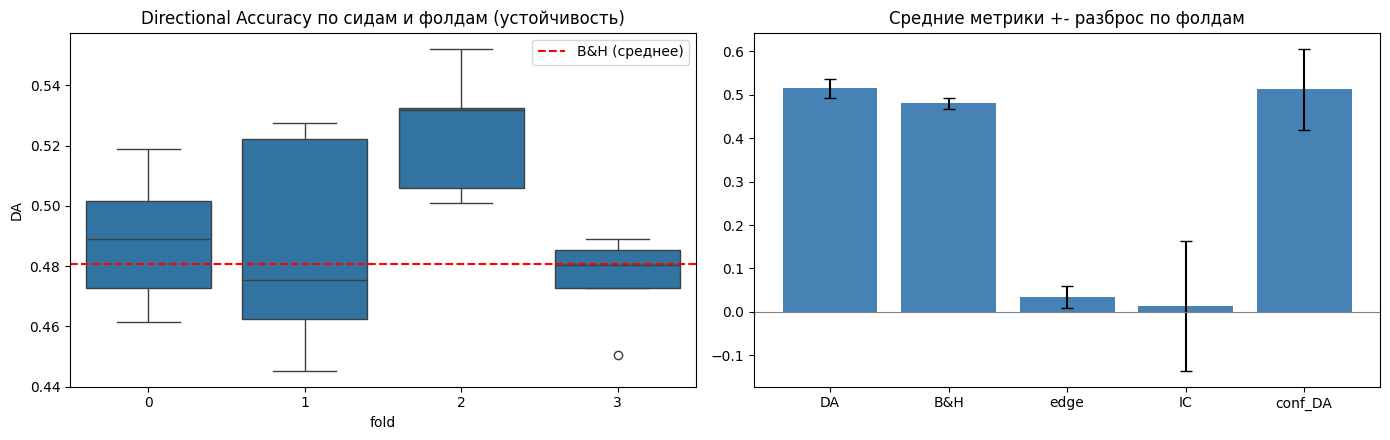

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
sns.boxplot(data=df_seeds, x='fold', y='DA', ax=ax[0])
ax[0].axhline(df_folds['B&H'].mean(), ls='--', c='red', label='B&H (среднее)')
ax[0].set_title('Directional Accuracy по сидам и фолдам (устойчивость)'); ax[0].legend()

m = summary.loc[['DA', 'B&H', 'edge', 'IC', 'conf_DA']]
ax[1].bar(m.index, m['mean'], yerr=m['std'], capsize=4, color='steelblue')
ax[1].axhline(0, c='gray', lw=0.8); ax[1].set_title('Средние метрики +- разброс по фолдам')
plt.tight_layout(); plt.show()

## 7. Диагностика последнего фолда: обучение, прогноз vs факт

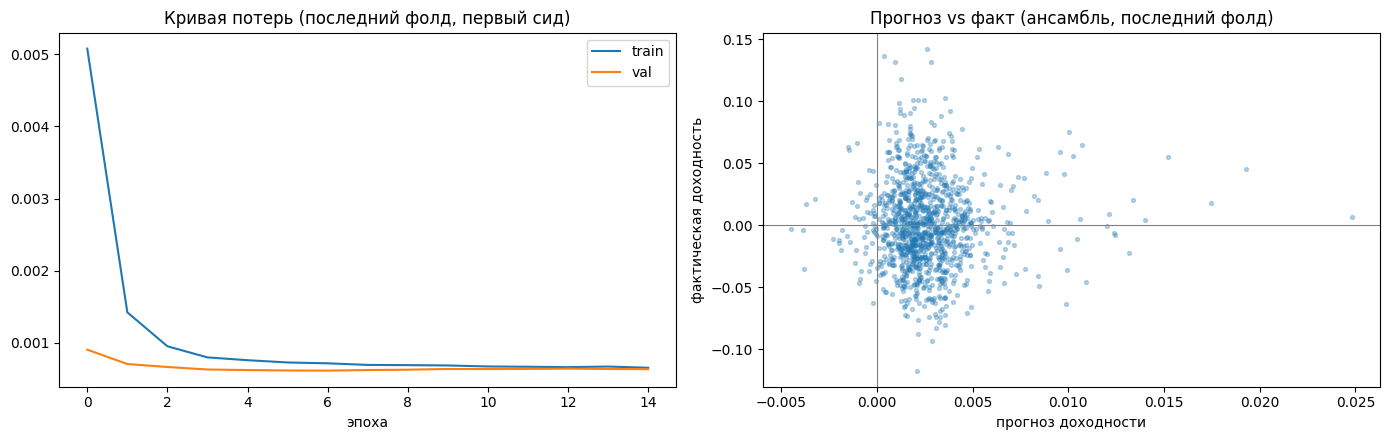

In [ ]:
h = last['history']
fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
ax[0].plot(h.history['loss'], label='train'); ax[0].plot(h.history['val_loss'], label='val')
ax[0].set_title('Кривая потерь (последний фолд, первый сид)'); ax[0].set_xlabel('эпоха'); ax[0].legend()

ax[1].scatter(last['ens'], last['yv'], s=8, alpha=0.3)
ax[1].axhline(0, c='gray', lw=0.8); ax[1].axvline(0, c='gray', lw=0.8)
ax[1].set_xlabel('прогноз доходности'); ax[1].set_ylabel('фактическая доходность')
ax[1].set_title('Прогноз vs факт (ансамбль, последний фолд)')
plt.tight_layout(); plt.show()

## 8. Разбивка по тикерам (последний фолд)

In [ ]:
rows = []
for name in np.unique(last['tv']):
    m = last['tv'] == name
    y, p = last['yv'][m], last['ens'][m]
    rows.append({'Ticker': name, 'DA': np.mean(np.sign(y) == np.sign(p)),
                 'B&H': np.mean(y > 0), 'Edge': np.mean(np.sign(y) == np.sign(p)) - np.mean(y > 0),
                 'IC': (np.corrcoef(p, y)[0, 1] if np.std(p) > 0 else np.nan),
                 'Up_forecasts': np.mean(p > 0), 'N': int(m.sum())})
per_ticker = pd.DataFrame(rows).sort_values('DA', ascending=False)
print(per_ticker.to_string(index=False, float_format=lambda x: f'{x:.3f}'))

Ticker    DA   B&H   Edge     IC  Up_forecasts   N
  SIBN 0.608 0.577  0.031 -0.010         0.892 130
  GAZP 0.585 0.600 -0.015  0.046         0.969 130
  LKOH 0.523 0.485  0.038  0.022         0.869 130
  TATN 0.500 0.469  0.031  0.072         0.954 130
  ROSN 0.485 0.508 -0.023 -0.198         0.931 130
 TATNP 0.454 0.438  0.015 -0.174         0.969 130
  NVTK 0.446 0.469 -0.023  0.170         0.977 130
  BANE 0.408 0.408  0.000 -0.141         1.000 130
 BANEP 0.369 0.377 -0.008 -0.094         0.992 130


## 9. Важность признаков (permutation importance)

Для каждого признака перемешиваем его значения по выборке и смотрим, насколько падает directional accuracy ансамбля. Чем больше падение — тем важнее признак. Усредняем по нескольким повторам, показываем разброс.

In [ ]:
def permutation_importance(models, Xv, yv, feature_cols, n_repeats=3):
    base = np.mean([m.predict(Xv, verbose=0).flatten() for m in models], axis=0)
    base_da = np.mean(np.sign(yv) == np.sign(base))
    rows = []
    for fi, fname in enumerate(feature_cols):
        drops = []
        for _ in range(n_repeats):
            Xp = Xv.copy()
            perm = np.random.permutation(Xp.shape[0])
            Xp[:, :, fi] = Xp[perm, :, fi]          # перемешиваем один признак
            pp = np.mean([m.predict(Xp, verbose=0).flatten() for m in models], axis=0)
            drops.append(base_da - np.mean(np.sign(yv) == np.sign(pp)))
        rows.append({'feature': fname, 'imp_mean': np.mean(drops), 'imp_std': np.std(drops)})
    return pd.DataFrame(rows).sort_values('imp_mean', ascending=False)

imp = permutation_importance(last['models'], last['Xv'], last['yv'], FEATURES, CONFIG['perm_repeats'])
plt.figure(figsize=(9, max(4, 0.35 * len(imp))))
top = imp.head(20)[::-1]
plt.barh(top['feature'], top['imp_mean'], xerr=top['imp_std'], capsize=3, color='teal')
plt.axvline(0, c='gray', lw=0.8)
plt.title('Важность признаков (падение directional accuracy при перемешивании)')
plt.tight_layout(); plt.show()
print(imp.round(4).to_string(index=False))

## 10. Сохранение артефактов (опционально)

In [ ]:
if CONFIG['save_dir']:
    import joblib
    os.makedirs(CONFIG['save_dir'], exist_ok=True)
    for i, m in enumerate(last['models']):
        m.save(os.path.join(CONFIG['save_dir'], f'reg_lstm_seed{i}.keras'))
    joblib.dump(last['scaler'], os.path.join(CONFIG['save_dir'], 'robust_scaler.pkl'))
    with open(os.path.join(CONFIG['save_dir'], 'features.json'), 'w') as f:
        json.dump(FEATURES, f, ensure_ascii=False)
    df_folds.to_csv(os.path.join(CONFIG['save_dir'], 'fold_metrics.csv'), index=False)
    imp.to_csv(os.path.join(CONFIG['save_dir'], 'feature_importance.csv'), index=False)
    print('Сохранено в', CONFIG['save_dir'])
else:
    print('save_dir = None — ничего не сохраняем')

save_dir = None — ничего не сохраняем


## Как читать результаты

- **DA (directional accuracy)** — доля верно угаданных направлений. Сравнивать надо не с 50%, а с **B&H** (долей дней роста): разница **edge** и есть реальное преимущество.
- **IC (информационный коэффициент)** — корреляция прогноза с фактической доходностью; для финансов даже 0.02–0.05 — это сигнал. Самая честная метрика для регрессии.
- **conf_DA** — точность на «уверенных» прогнозах (верхние по модулю). Если она заметно выше обычной DA — значит модель «знает, когда знает», и осмысленно торговать только уверенными сигналами.
- **Разброс (std) по фолдам и по сидам** — мера устойчивости. Если edge положительный в среднем, но std перекрывает ноль — преимущество неустойчиво (это тоже честный результат).

## Как менять (через CONFIG)
- горизонт/окно: `horizon`, `window_size`;
- набор бумаг: `exclude_tickers` (или соберите расширенный `full_df_sector.csv` и укажите его путь);
- быстрый прогон: `scheme='holdout'`; надёжная оценка устойчивости: `scheme='walk_forward'`, больше `n_folds`;
- размер ансамбля: список `seeds`; архитектура/обучение: блок `model`.